```
<09_apple_banana_orange.ipynb>

제미나이 의존도: 60-70%

캐글에서 xml 파일이 포함되어 있는 객체 탐지 데이터셋을 가져왔다.
한번쯤은 xml 파일을 분해해서 txt 파일로 변환하고 싶었다.
몇번 안해봐서 아직 낯설다. 어렵진 않지만..

모델 학습 후 혼동 행렬을 확인해 봤는데, 대체로 정답박스와 비슷하게 예측했지만, 이상한 점도 확인했다.
포도는 클래스에 포함이 안되어 있는데, 이미지 중에 포도 이미지도 있었다. 그래서 모델 입장에서는 사과, 바나나, 오렌지 중 그나마 유사한 사과로 예측했다. 하지만 정답지 입장에서는 background이므로 오탐이 되어버린 것이다.
이건 모델이 잘못 예측했다 문제가 아니라 정제되지 않은 데이터 탓이 아닐까 싶다.
```

In [1]:
import xml.etree.ElementTree as ET
import os
import cv2
import shutil
from ultralytics import YOLO
import time
%matplotlib inline
import matplotlib.pyplot as plt
import torch

In [12]:
def convert_bbox(size, box):
    # size: (img_width, img_height)
    # box: (xmin, ymin, xmax, ymax)
    # return: (x_center, y_center, width, height) 0~1 값

    img_width = size[0]
    img_height = size[1]

    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    
    dw = 1.0 / img_width
    dh = 1.0 / img_height

    x_center = dw * (xmin + xmax) / 2
    y_center = dh * (ymin + ymax) / 2
    w = (xmax - xmin) * dw
    h = (ymax - ymin) * dh

    # 안전장치: 0.0 ~ 1.0 범위를 벗어나지 않도록 제한 (Clipping)
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))

    return (x_center, y_center, w, h)

def parse_xml_to_txt(image_and_xml_dir, pure_name, ext, split_name):
    class_mapping = {"apple": 0, "banana": 1, "orange": 2}

    xml_path = os.path.join(image_and_xml_dir, f"{pure_name}.xml")

    if not os.path.exists(xml_path):
        return []
    
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # 이미지 크기 추출
    size = root.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    # width/height가 0이면 실제 이미지 파일에서 크기를 읽어온다.
    if w == 0 or h == 0:
        # filename = root.find('filename').text
        image_path = os.path.join(image_and_xml_dir, f"{pure_name}{ext}")

        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            if img is not None:
                h, w, _ = img.shape
            else:
                return [] # 이미지 파일이 깨졌다면 이 파일은 건너뜀
        else:
            return [] # 이미지 파일이 없으면 건너뜀
    

    yolo_labels = []

    # 객체 태그 반복문
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in class_mapping:
            continue

        class_id = class_mapping[class_name]
        xmlbox = obj.find('bndbox')

        b = (float(xmlbox.find('xmin').text), 
             float(xmlbox.find('ymin').text), 
             float(xmlbox.find('xmax').text), 
             float(xmlbox.find('ymax').text))

        # 좌표 변환 호출
        bb = convert_bbox((w, h), b)

        # YOLO 포맷: "class_id x_center y_center width, height"
        yolo_labels.append(f"{class_id} {bb[0]:.6f} {bb[1]:.6f} {bb[2]:.6f} {bb[3]:.6f}")

    if not yolo_labels:
        return []

    # save_path = "dataset/fruits/fruit-images-for-object-detection/train_zip"
    save_path = f"dataset/fruits/{split_name}"

    # 이미지 복사
    image_src_path = os.path.join(image_and_xml_dir, f"{pure_name}{ext}")
    image_dest_path = os.path.join(save_path, f"images/{pure_name}{ext}")
    shutil.copy(image_src_path, image_dest_path)

    # txt 라벨 파일 저장 (join 메소드로 개행 깔끔히 처리)
    txt_save_path = os.path.join(save_path, f"labels/{pure_name}.txt")
    
    with open(txt_save_path, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_labels))
                
    return yolo_labels

In [7]:
xml_path = "dataset/fruits/fruit-images-for-object-detection/train_zip/train/mixed_1.xml"
image_dir = "dataset/fruits/fruit-images-for-object-detection/train_zip/train"
class_mapping = {"apple": 0, "banana": 1, "orange": 2}
yolo_labels = parse_xml_to_txt(xml_path, image_dir, class_mapping)
print(yolo_labels)

['2 0.427500 0.373227 0.302500 0.452128', '0 0.691250 0.489362 0.282500 0.453901', '1 0.425625 0.670213 0.716250 0.531915']


```
일단.. 캐글에서 xml이 있는 객체 탐지 데이터셋을 다운받았는데, 한 폴더 안에 xml, image가 있었다.
다른 데이터셋도 그런진 모르겠지만, 일단 이 데이터셋 기준으로 함수를 재구성 해보자.
xml 파일을 파싱해서 yolo_labels를 만들고, 만든 것으로 txt 파일에 writeline을 해서 내가 새로 만든 labels 폴더에 넣을거다.
일단 해보자.. just do it
```

In [16]:
common_path = "dataset/fruits/fruit-images-for-object-detection"
# image_and_xml_dir = "dataset/fruits/fruit-images-for-object-detection/train_zip/train"

split_maps = {"train": {"image_and_xml_dir": os.path.join(common_path, "train_zip/train")}, 
             "valid": {"image_and_xml_dir": os.path.join(common_path, "test_zip/test")}}

for split_name, info in split_maps.items():
    images = [f for f in os.listdir(info["image_and_xml_dir"]) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    # print(len(images))
    # print(split_name)
    # break
    for image in images:
        pure_name, ext = os.path.splitext(image)
        parse_xml_to_txt(info["image_and_xml_dir"], pure_name, ext, split_name)




libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


In [22]:
images_and_xml_dir = "dataset/fruits/fruit-images-for-object-detection/test_zip/test"
images = [f for f in os.listdir(image_and_xml_dir) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

for image in images:
    pure_name, ext = os.path.splitext(image)
    parse_xml_to_txt(image_and_xml_dir, pure_name, ext)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


In [18]:
with open("dataset/fruits/data.yaml", "w", encoding="utf-8") as f:
    f.write("train: ../train/images\n")
    f.write("val: ../valid/images\n")
    f.write("\n")
    f.write("nc: 3\n")
    f.write("names: ['apple', 'banana', 'orange']")

In [20]:
model = YOLO("yolov8n.pt")

current_dir = os.getcwd()

start_time = time.time()
model.train(
    data="dataset/fruits/data.yaml", 
    epochs=30, 
    imgsz=640, 
    device="mps", 
    project=os.path.join(current_dir, "runs"), 
    name="apple_banana_orange"
)

end_time = time.time()
elapsed_time = int(end_time - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"{mins}:{secs}")


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/fruits/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=apple_banana_orange,

libpng warning: iCCP: known incorrect sRGB profile


       1/30      4.28G      1.185      3.152       1.51         75        640: 26% ━━━───────── 4/15 1.1s/it 5.1s<12.4s

libpng warning: iCCP: known incorrect sRGB profile


       1/30      4.27G      1.176      3.093      1.504         91        640: 53% ━━━━━━────── 8/15 1.2it/s 8.4s<6.1s

...

      30/30      4.28G     0.6611     0.7581      1.091         23        640: 100% ━━━━━━━━━━━━ 15/15 1.4it/s 11.1s0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 1/2 2.6s/it 0.8s<2.6s

libpng warning: iCCP: known incorrect sRGB profile


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.6s
                   all         60        117      0.908      0.838      0.926      0.686

30 epochs completed in 0.118 hours.
Optimizer stripped from /Users/jeongjaehun/Github/03_object_detection/runs/apple_banana_orange/weights/last.pt, 6.2MB
Optimizer stripped from /Users/jeongjaehun/Github/03_object_detection/runs/apple_banana_orange/weights/best.pt, 6.2MB

Validating /Users/jeongjaehun/Github/03_object_detection/runs/apple_banana_orange/weights/best.pt...
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 1/2 2.2s/it 0.7s<2.2s

libpng warning: iCCP: known incorrect sRGB profile


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         60        117      0.908      0.838      0.926      0.687
                 apple         24         35      0.832      0.914       0.91      0.757
                banana         22         40      0.921      0.825      0.896      0.575
                orange         22         42       0.97      0.775      0.972      0.729
Speed: 0.1ms preprocess, 7.3ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /Users/jeongjaehun/Github/03_object_detection/runs/apple_banana_orange
7:16


In [6]:
def inspect_detection(image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO("runs/apple_banana_orange/weights/best.pt")
    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device="cpu"
    )

    # if preds[0].boxes is not None:
    #     preds[0].boxes.data = preds[0].boxes.data.clone()

    annotated_img = preds[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.title(f"Conf: {conf_threshold} | IoU: {iou_threshold}", fontsize=12)
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/fruits/valid/images/mixed_23.jpg: 480x640 5 apples, 1 banana, 1 orange, 28.4ms
Speed: 1.6ms preprocess, 28.4ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


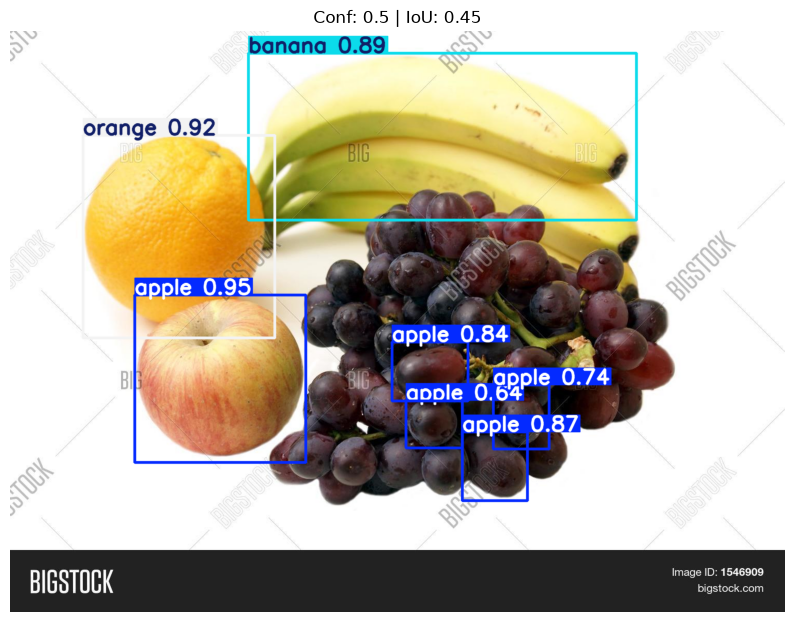

In [8]:
image_path = "dataset/fruits/valid/images/mixed_23.jpg"
inspect_detection(image_path, conf_threshold=0.5, iou_threshold=0.45)

In [31]:
# 모델 검증 수행

model = YOLO("runs/apple_banana_orange/weights/best.pt")

metrics = model.val(
    data="dataset/fruits/data.yaml", 
    project=os.path.join(current_dir, "validation"), 
    name="apple_banana_orange"
)

print(metrics.box.map50)
print(metrics.box.map)

Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 496.9±353.3 MB/s, size: 187.0 KB)
val: Scanning /Users/jeongjaehun/Github/03_object_detection/dataset/fruits/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 50.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 50% ━━━━━━────── 2/4 2.7s/it 2.8s<5.5ss

libpng warning: iCCP: known incorrect sRGB profile


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3s/it 5.1s2.4s
                   all         60        117      0.911      0.836      0.926      0.695
                 apple         24         35      0.834      0.914       0.91      0.768
                banana         22         40      0.929      0.825      0.896      0.587
                orange         22         42       0.97       0.77      0.972       0.73
Speed: 0.3ms preprocess, 78.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /Users/jeongjaehun/Github/03_object_detection/validation/apple_banana_orange
0.9263105062575491
0.6948632560289095
